In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/sample_submission.csv
/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/train.csv
/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/test.csv


In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder , LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

import warnings

warnings.filterwarnings('ignore')

In [3]:
train = pd.read_csv('/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/train.csv')
train.head()

,ID,mushroom_id,cap-shape,cap-surface,cap-color,bruises,number_of_bruises,odor,gill-attachment,gill-spacing,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,1,0,convex,smooth,brown,bruises,7,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
1,2,1,convex,smooth,yellow,bruises,20,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,brown,numerous,grasses,e
2,3,3,convex,scaly,white,bruises,11,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
3,4,4,convex,smooth,gray,no,0,NaN,gills free from stalk,crowded,...,white,white,partial,white,1.0,evanescent,brown,abundant,grasses,e
4,5,5,convex,scaly,yellow,bruises,8,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,numerous,grasses,e


In [4]:
test = pd.read_csv('/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/test.csv')
test.head()

,ID,mushroom_id,cap-shape,cap-surface,cap-color,bruises,number_of_bruises,odor,gill-attachment,gill-spacing,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,2,bell,smooth,white,bruises,15,anise,gills free from stalk,close,...,smooth,white,white,partial,white,1,pendant,brown,numerous,meadows
1,2,6,bell,smooth,white,bruises,21,almond,gills free from stalk,close,...,smooth,white,white,partial,white,1,pendant,black,numerous,meadows
2,3,7,bell,scaly,white,bruises,7,anise,gills free from stalk,close,...,smooth,white,white,partial,white,1,pendant,brown,scattered,meadows
3,4,9,bell,smooth,yellow,bruises,23,almond,gills free from stalk,close,...,smooth,white,white,partial,white,1,pendant,black,scattered,meadows
4,5,11,convex,scaly,yellow,bruises,11,almond,gills free from stalk,close,...,smooth,white,white,partial,white,1,pendant,black,scattered,meadows


In [5]:
print(train.shape)
print(test.shape)

(7000, 26)
(1124, 25)


# Criteria 1 --> Identify data types of different columns

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        7000 non-null   int64  
 1   mushroom_id               7000 non-null   int64  
 2   cap-shape                 7000 non-null   object 
 3   cap-surface               7000 non-null   object 
 4   cap-color                 7000 non-null   object 
 5   bruises                   7000 non-null   object 
 6   number_of_bruises         7000 non-null   int64  
 7   odor                      3764 non-null   object 
 8   gill-attachment           7000 non-null   object 
 9   gill-spacing              7000 non-null   object 
 10  gill-size                 7000 non-null   object 
 11  gill-color                7000 non-null   object 
 12  stalk-shape               7000 non-null   object 
 13  stalk-root                6808 non-null   object 
 14  stalk-su

# Criteria 2 --> Present descriptive statistics of numerical columns

In [7]:
train.describe()

,ID,mushroom_id,number_of_bruises,ring-number
count,7000.000000,7000.000000,7000.000000,6964.000000
mean,3500.500000,3850.617714,5.459571,1.080988
std,2020.870275,2208.389867,7.723528,0.272836
min,1.000000,0.000000,0.000000,1.000000
25%,1750.750000,2000.750000,0.000000,1.000000
50%,3500.500000,3755.500000,0.000000,1.000000
75%,5250.250000,5602.250000,11.000000,1.000000
max,7000.000000,8118.000000,24.000000,2.000000


# Criteria 3 --> Identify and handle the missing values

First removing the redundant columns

In [8]:
#removing columns which is not contributing the problem solving
id = test['ID']
train.drop(columns = ['ID','mushroom_id'] , axis=1 , inplace = True)
test.drop(columns = ['ID','mushroom_id'] , axis=1 , inplace = True)


In [9]:
#removing the columns with 0 variance(with same entries in every row)
print(train['veil-color'].value_counts())
print(train['veil-type'].value_counts())

#So veil-color and veil-type should be dropped
train.drop(columns = ['veil-color','veil-type'],axis =1,inplace= True)
test.drop(columns = ['veil-color','veil-type'],axis =1,inplace= True)

veil-color
white    7000
Name: count, dtype: int64
veil-type
partial    7000
Name: count, dtype: int64


Now imputing the Nan values 

In [10]:
train.isnull().sum()

cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
number_of_bruises              0
odor                        3236
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                   192
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
ring-number                   36
ring-type                     36
spore-print-color              0
population                     0
habitat                        0
class                          0
dtype: int64

In [11]:
train['odor'].value_counts()

odor
foul        1968
fishy        384
spicy        384
almond       272
anise        272
pungent      256
creosote     192
musty         36
Name: count, dtype: int64

In [12]:
train['stalk-root'].value_counts()

stalk-root
bulbous    3684
missing    1712
equal      1120
club        292
Name: count, dtype: int64

In [13]:
X_train = train.drop(columns=['class'] , axis=1)
y_train = train['class']

X_test = test

X_test.shape

(1124, 21)

In [14]:
imputer = ColumnTransformer(
    transformers=[
        ('odor_imp', SimpleImputer(strategy='constant', fill_value='none'), ['odor']),
        
        ('stalk_imp', SimpleImputer(strategy='constant', fill_value='missing'), ['stalk-root']),
        
        ('mode_imp', SimpleImputer(strategy='most_frequent'), ['ring-number','ring-type'])
    ],
    remainder='passthrough' ,

    verbose_feature_names_out=False
)

imputer.set_output(transform='pandas')

ColumnTransformer(remainder='passthrough',
                  transformers=[('odor_imp',
                                 SimpleImputer(fill_value='none',
                                               strategy='constant'),
                                 ['odor']),
                                ('stalk_imp',
                                 SimpleImputer(fill_value='missing',
                                               strategy='constant'),
                                 ['stalk-root']),
                                ('mode_imp',
                                 SimpleImputer(strategy='most_frequent'),
                                 ['ring-number', 'ring-type'])],
                  verbose_feature_names_out=False)

In [15]:
train_imputed = imputer.fit_transform(X_train)
test_imputed = imputer.transform(X_test)

# Criteria 4--> Checking for duplicates

In [16]:
# 1. Create a mask of rows that are duplicates
duplicate_mask = train_imputed.duplicated(keep='first')
train_dup = duplicate_mask.sum()

if train_dup > 0:
    print(f"Number of duplicates in train set: {train_dup}")
    
    # 2. Keep only the rows where duplicate_mask is False (using the ~ symbol)
    train_imputed = train_imputed[~duplicate_mask]
    y_train = y_train[~duplicate_mask]
else:
    print("No duplicates are there")

No duplicates are there


# Criteria 5 --> Identifying and Handling Outliers

In [17]:
# Checking for Outliers for 'number of bruises' using Interquartile Range
Q1 = train_imputed['number_of_bruises'].quantile(0.25)
Q3 = train_imputed['number_of_bruises'].quantile(0.75)

IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR
lower = Q1 - 1.5 * IQR

# 1. Create a mask for rows that are NOT outliers (the "safe" rows)
safe_rows_mask = (train_imputed['number_of_bruises'] >= lower) & (train_imputed['number_of_bruises'] <= upper)

# Count how many outliers we have by checking how many are NOT safe
outliers_count = (~safe_rows_mask).sum()

if outliers_count > 0:
    print(f"Total number of outliers is/are {outliers_count}")
    
    # 2. Apply the safe mask to BOTH datasets!
    train_imputed = train_imputed[safe_rows_mask]
    y_train = y_train[safe_rows_mask]
else:
    print("No outliers found")

No outliers found


# Criteria 6--> Present at least three visualizations and provide insights for the same

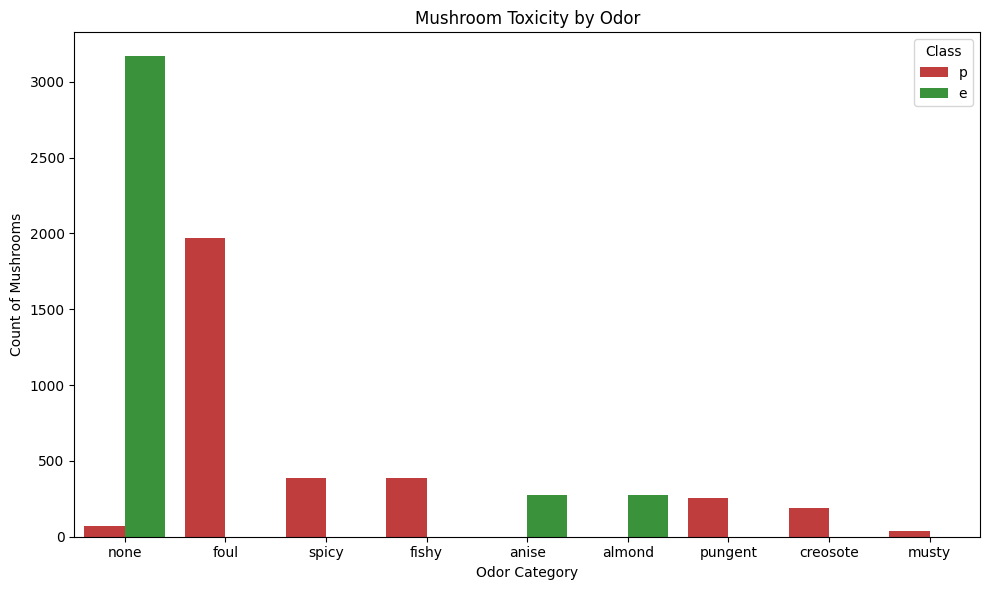

In [18]:
#Visualization 1 --> This plots the relationship between the mushroom's smell and its toxicity.
plt.figure(figsize=(10, 6))

order = train_imputed['odor'].value_counts().index

sns.countplot(data=train_imputed, x='odor', hue=y_train, order=order, 
              palette={'e': '#2ca02c', 'p': '#d62728'})

plt.title('Mushroom Toxicity by Odor')
plt.xlabel('Odor Category')
plt.ylabel('Count of Mushrooms')
plt.legend(title='Class')

plt.tight_layout()
plt.show()

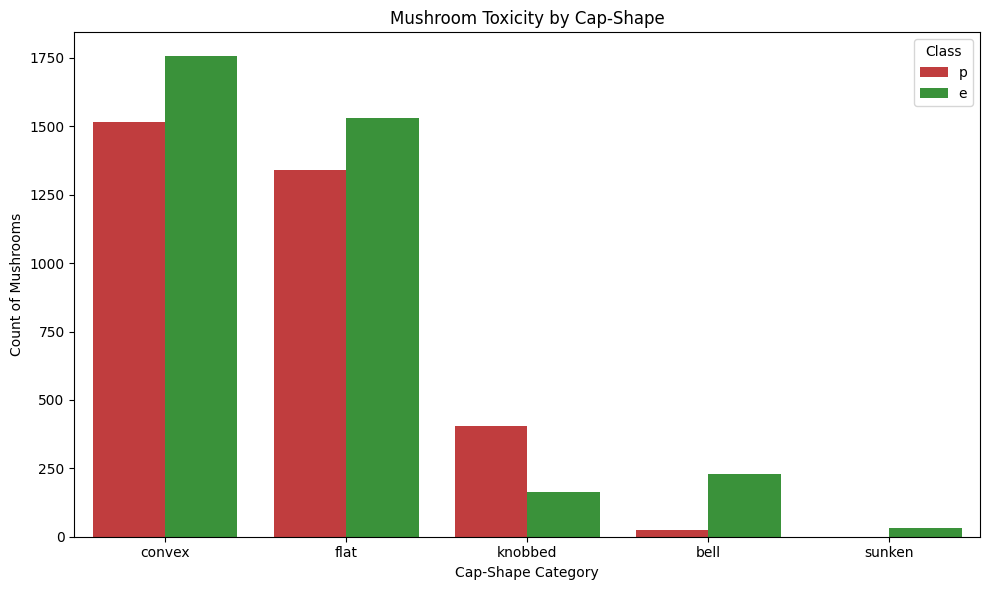

In [19]:
#Visualization 2 --> This plots the relationship between the mushroom's cape-shape and its toxicity.
plt.figure(figsize=(10, 6))

capshape = train_imputed['cap-shape'].value_counts().index

sns.countplot(data=train_imputed, x='cap-shape', hue=y_train, order=capshape, 
              palette={'e': '#2ca02c', 'p': '#d62728'})

plt.title('Mushroom Toxicity by Cap-Shape')
plt.xlabel('Cap-Shape Category')
plt.ylabel('Count of Mushrooms')
plt.legend(title='Class')

plt.tight_layout()
plt.show()

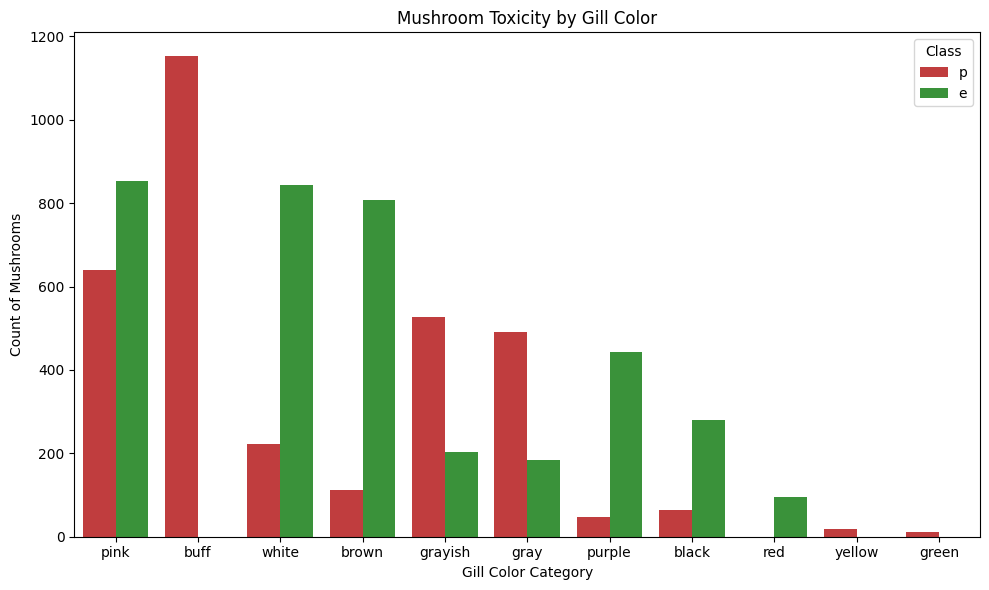

In [20]:
#Visualization 3 --> This plots the relationship between the mushroom's gill color and its toxicity.
plt.figure(figsize=(10, 6))

gill_color = train_imputed['gill-color'].value_counts().index

sns.countplot(data=train_imputed, x='gill-color', hue=y_train, order=gill_color, 
              palette={'e': '#2ca02c', 'p': '#d62728'})

plt.title('Mushroom Toxicity by Gill Color')
plt.xlabel('Gill Color Category')
plt.ylabel('Count of Mushrooms')
plt.legend(title='Class')

plt.tight_layout()
plt.show()

# Criteria 7 --> Scale Numerical features and Encode Categorical features

In [21]:
X_train = train_imputed

X_test = test_imputed 


In [22]:
num_cols = X_train.select_dtypes(include='number').columns.to_list()

cat_cols = X_train.select_dtypes(include='object').columns.to_list()

print("Numerical Columns are :",num_cols)
print("----------------------------------------------------------------------------------------")
print("Categorical Columns are :" ,cat_cols)

Numerical Columns are : ['number_of_bruises']
----------------------------------------------------------------------------------------
Categorical Columns are : ['odor', 'stalk-root', 'ring-number', 'ring-type', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'spore-print-color', 'population', 'habitat']


In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        # Apply StandardScaler to the 2 numerical columns
        ('num_scaler', StandardScaler(), num_cols),
        
        # Apply OneHotEncoder to the 19 categorical columns
        ('cat_encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_cols)
    ],
    verbose_feature_names_out=False 
)

preprocessor.set_output(transform='pandas')

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

X_test = X_test_encoded

print(f"Original X_train shape: {X_train.shape}")
print(f"Encoded X_train shape: {X_train_encoded.shape}")

Original X_train shape: (7000, 21)
Encoded X_train shape: (7000, 99)


In [24]:
le = LabelEncoder()
y_train_encoded = pd.DataFrame(le.fit_transform(y_train))

# Criteria 8 --> Model Building

In [25]:
#splitting data for test and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_train_encoded,
    y_train_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_train_encoded
)

In [26]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Support Vector Machine (SVC)": SVC(random_state=42),
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(),
    "Naive Bayes (Gaussian)": GaussianNB()
}

In [27]:
validation_scores = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    preds_val = model.predict(X_val)

    acc = accuracy_score(y_val, preds_val)

    validation_scores[name] = acc

    print(f"{name} validation accuracy: {acc:.3f}")

Logistic Regression validation accuracy: 1.000
Decision Tree validation accuracy: 1.000
Random Forest validation accuracy: 1.000
Gradient Boosting validation accuracy: 1.000
Support Vector Machine (SVC) validation accuracy: 1.000
K-Nearest Neighbors (KNN) validation accuracy: 1.000
Naive Bayes (Gaussian) validation accuracy: 1.000


# Criteria 9 --> Hyperparameter Tuning

In [28]:
models_to_tune = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

param_grids =param_grids = {
    "Logistic Regression": {'C': [0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']},
    "Decision Tree": {'max_depth': [None, 10, 20], 'criterion': ['gini', 'entropy']},
    "Random Forest": {'n_estimators': [50, 100], 'max_depth': [None, 10]},
    "Gradient Boosting": {'n_estimators': [50, 100], 'learning_rate': [0.1, 0.05]},
    "SVM": {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']},
    "KNN": {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']},
    "Naive Bayes": {'var_smoothing': [1e-9, 1e-8]} 
}

best_models = {}

print("Starting Hyperparameter Tuning...")

for name, model in models_to_tune.items():
    print(f"Tuning {name}...")

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=5,               
        scoring='accuracy',  
        n_jobs=-1             
    )
    
    grid_search.fit(X_train, y_train.to_numpy().ravel())
    
    best_models[name] = grid_search.best_estimator_

    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best Cross-Validation Accuracy: {grid_search.best_score_ * 100:.2f}%\n")

print("Tuning Complete!")

Starting Hyperparameter Tuning...
Tuning Logistic Regression...
Best Parameters: {'C': 1, 'solver': 'lbfgs'}
Best Cross-Validation Accuracy: 100.00%

Tuning Decision Tree...
Best Parameters: {'criterion': 'gini', 'max_depth': None}
Best Cross-Validation Accuracy: 100.00%

Tuning Random Forest...
Best Parameters: {'max_depth': None, 'n_estimators': 50}
Best Cross-Validation Accuracy: 100.00%

Tuning Gradient Boosting...
Best Parameters: {'learning_rate': 0.1, 'n_estimators': 50}
Best Cross-Validation Accuracy: 100.00%

Tuning SVM...
Best Parameters: {'C': 0.1, 'kernel': 'linear'}
Best Cross-Validation Accuracy: 100.00%

Tuning KNN...
Best Parameters: {'n_neighbors': 3, 'weights': 'uniform'}
Best Cross-Validation Accuracy: 100.00%

Tuning Naive Bayes...
Best Parameters: {'var_smoothing': 1e-09}
Best Cross-Validation Accuracy: 99.89%

Tuning Complete!


# Criteria 10 --> Comparision of Model Performances

In [29]:
tuned_val_scores = {}

print("Evaluating optimized models on the Validation Set...\n")

for name, model in best_models.items():
    
    y_val_pred = model.predict(X_val)
    
    acc = accuracy_score(y_val.squeeze(), y_val_pred)
    
    tuned_val_scores[name] = acc * 100
    print(f"{name}: {acc * 100:.2f}%")

comparison_df = pd.DataFrame(list(tuned_val_scores.items()), columns=['Model', 'Validation Accuracy (%)'])
comparison_df = comparison_df.sort_values(by='Validation Accuracy (%)', ascending=False)

Evaluating optimized models on the Validation Set...

Logistic Regression: 100.00%
Decision Tree: 100.00%
Random Forest: 100.00%
Gradient Boosting: 100.00%
SVM: 100.00%
KNN: 100.00%
Naive Bayes: 100.00%


In [30]:
final_model = best_models["Random Forest"]
final_model.fit(X_train_encoded, y_train_encoded.values.ravel())

test_predictions = final_model.predict(X_test)

final_labels = le.inverse_transform(test_predictions)

submission = pd.DataFrame({
    'ID': id, 
    'class': final_labels
})

submission.to_csv('mushroom_submission.csv', index=False)

print(submission.head())


   ID class
0   1     e
1   2     e
2   3     e
3   4     e
4   5     e
